In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
#EDA
df = pd.read_csv('bank-full.csv', delimiter=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
#null check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Text(0.5, 1.0, 'Distribution of Target Variable (y)')

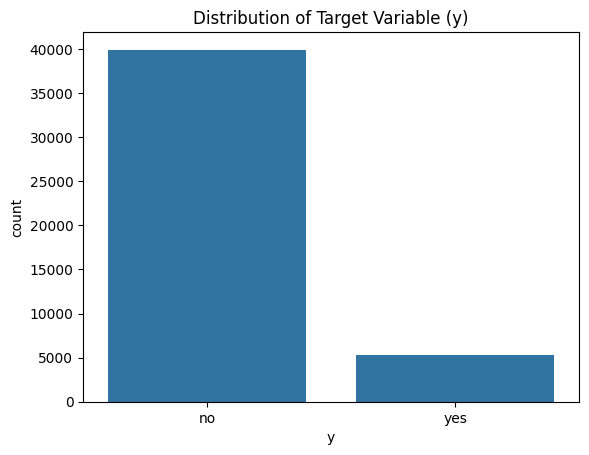

In [7]:
sns.countplot(x='y', data=df)
plt.title('Distribution of Target Variable (y)')

In [8]:
df["y"]=df["y"].map({'yes':1,'no':0})
df["y"].value_counts(normalize=True)

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

#indicates imbalance with 88.3 % belonging to the yes "NO" class asnd only 11.7 % belonging to the yes class

In [9]:
def plot_facet_grid(feature, bins):
    g = sns.FacetGrid(df, col='y', height=5, aspect=1.2)
    g.map(sns.histplot, feature, bins=bins, color='#3498db', kde=False)
    g.set_titles(col_template='Target = {col_name}')
    g.set_axis_labels(feature, "Count")
    g.fig.suptitle(f"{feature} Distribution by Term Deposit Subscription", y=1.05)
    plt.tight_layout()
    plt.show()

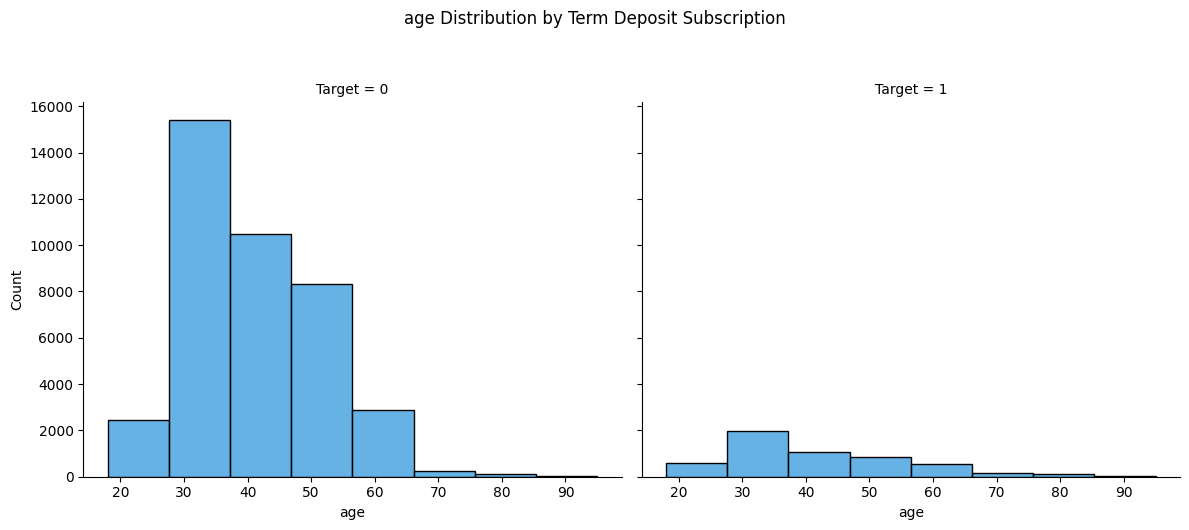

In [10]:
plot_facet_grid('age',8)

In [11]:
def plot_TargetbyCat(feature, bar_height=0.5, height_per_row=0.6):
    job_counts_abs = pd.crosstab(df[feature], df['y']).sort_values(by=1, ascending=False)
    jobs = job_counts_abs.index
    counts_no = job_counts_abs[0]
    counts_yes = job_counts_abs[1]

    # Dynamically set height based on number of categories
    dynamic_height = max(4, len(jobs) * height_per_row)
    fig, ax = plt.subplots(figsize=(12, dynamic_height))

    bar_min_width = 200

    bar_no = ax.barh(jobs, counts_no, color='#5DADE2', label='No (0)', height=bar_height)
    bar_yes = ax.barh(jobs, counts_yes, left=counts_no, color='#1ABC9C', label='Yes (1)', height=bar_height)

    for i, (no, yes) in enumerate(zip(counts_no, counts_yes)):
        total = no + yes
        yes_pct = f'{yes / total:.1%}'
        no_pct = f'{no / total:.1%}'

        ax.text(no / 2, i, no_pct, va='center', ha='center', color='white', fontsize=9)

        if yes > bar_min_width:
            ax.text(no + yes / 2, i, yes_pct, va='center', ha='center', color='white', fontsize=9)
        else:
            ax.text(no + yes + 50, i, yes_pct, va='center', ha='left', color='black', fontsize=9)

    ax.set_xlabel("Number of Records")
    ax.set_title(f"Term Deposit Subscriptions by {feature} (Absolute Count & Proportion)")
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

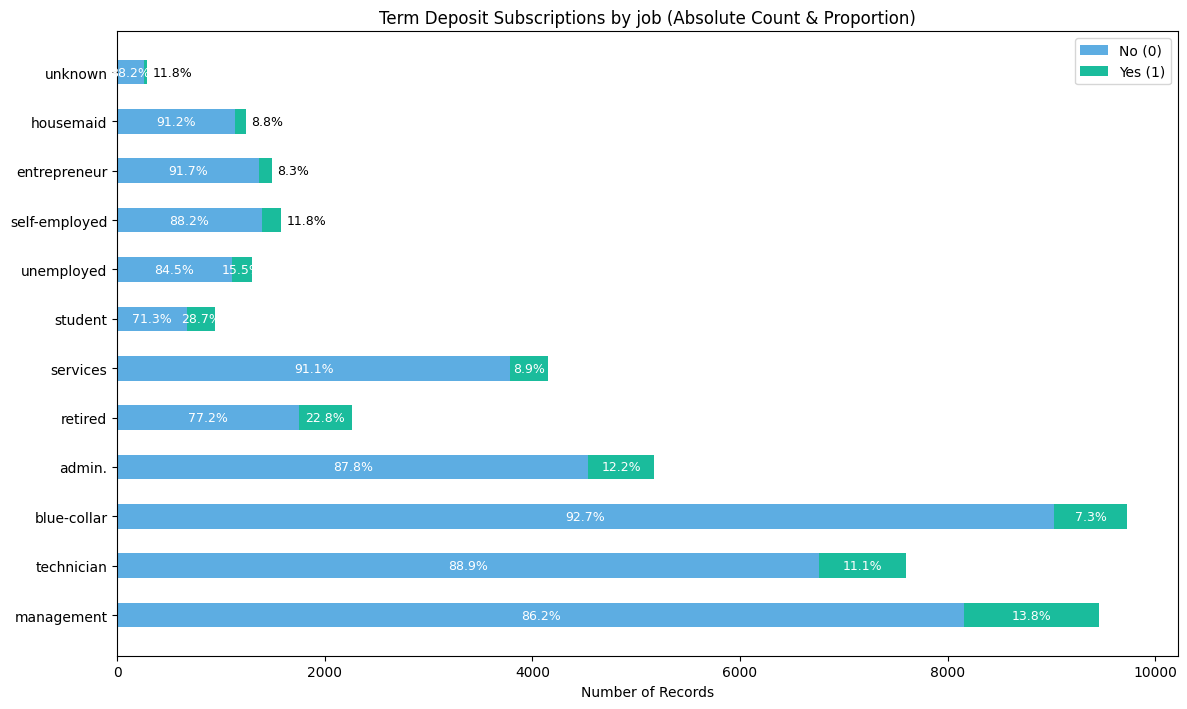

In [12]:
plot_TargetbyCat('job')

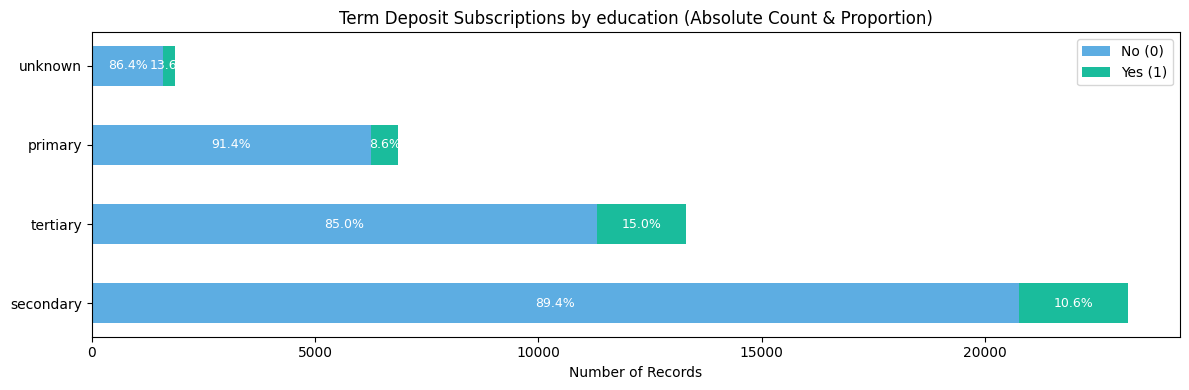

In [13]:
plot_TargetbyCat('education')

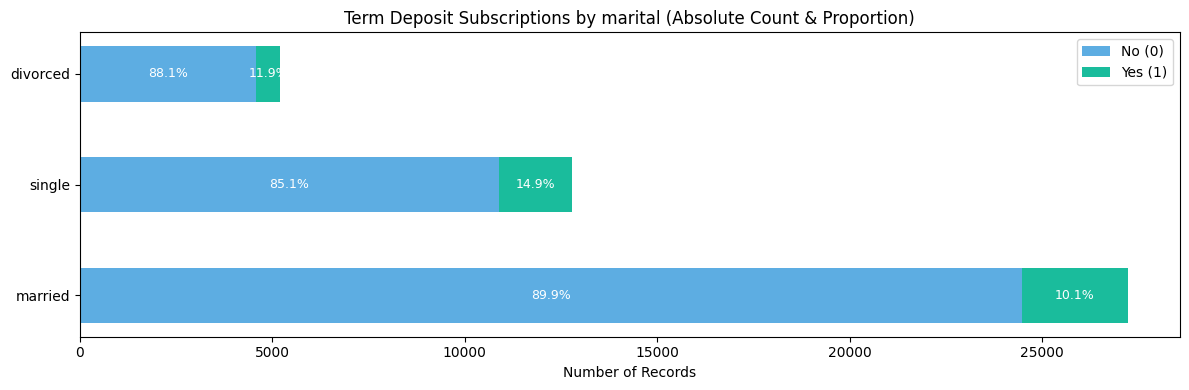

In [14]:
plot_TargetbyCat('marital')

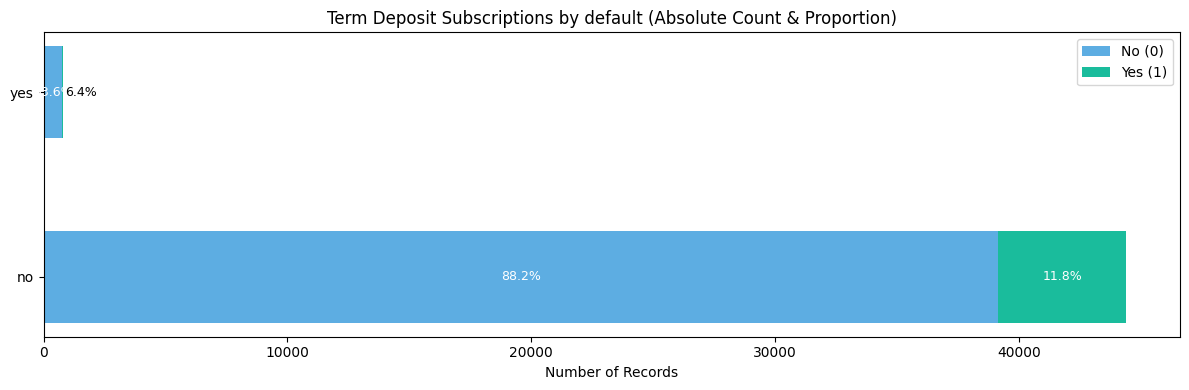

In [15]:
#people with default are less likely to subscribe to term deposit than those without default
plot_TargetbyCat('default')

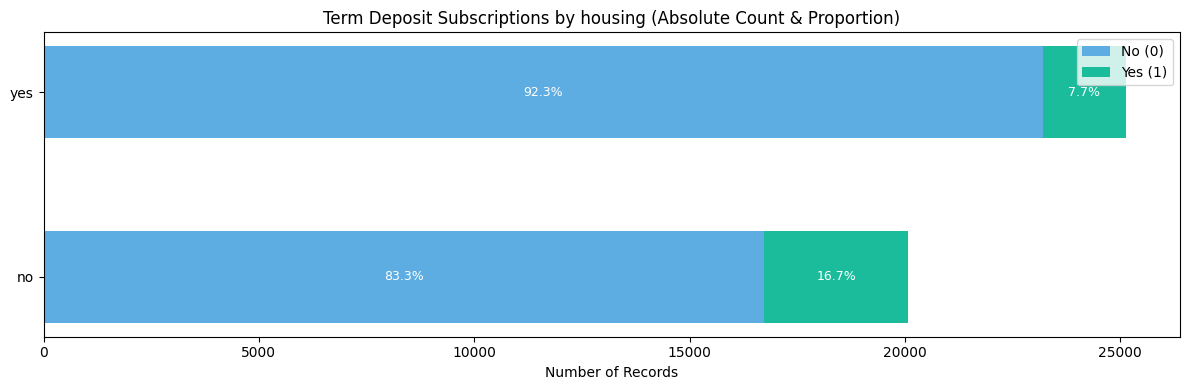

In [16]:
#people with house loan are less likely to subscribe to term deposit than those without house loan
plot_TargetbyCat('housing')

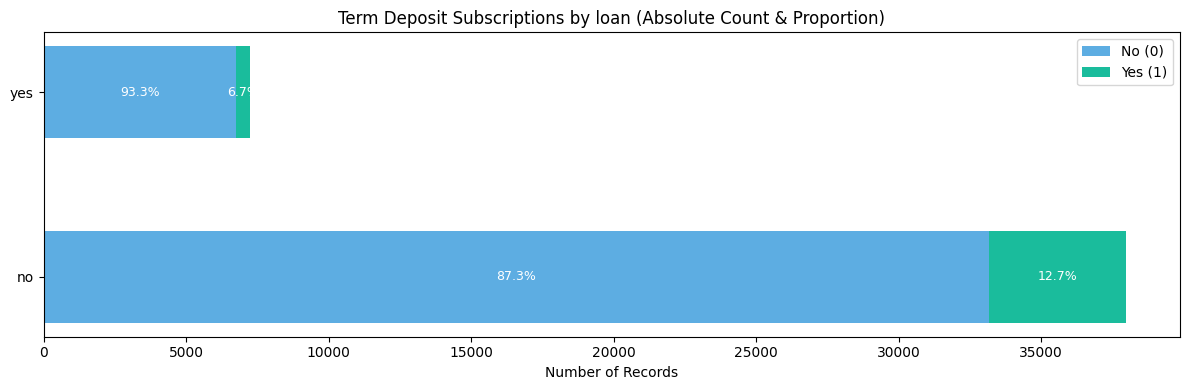

In [17]:
plot_TargetbyCat('loan')

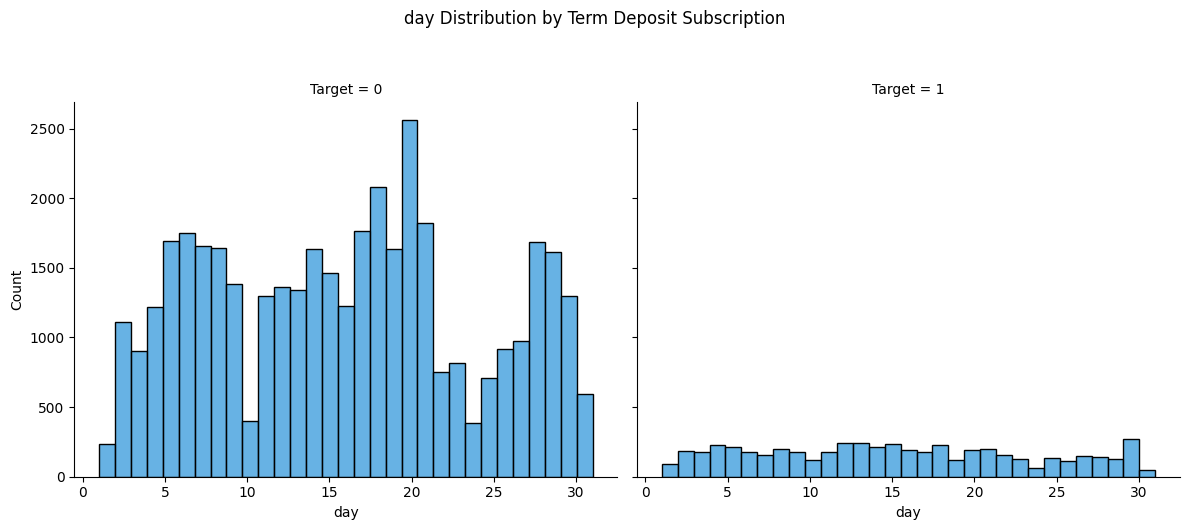

In [18]:
plot_facet_grid("day",31)

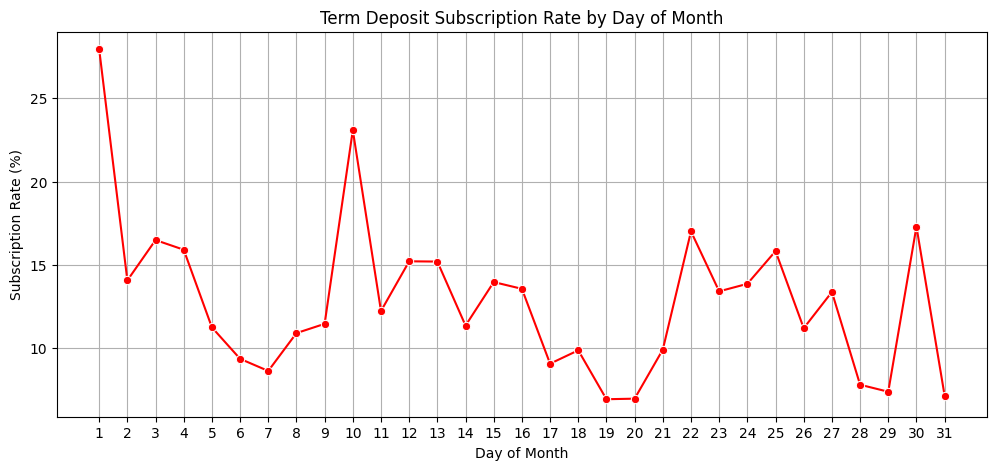

In [19]:
conversion_by_day = df.groupby('day')['y'].mean() * 100

plt.figure(figsize=(12, 5))
sns.lineplot(x=conversion_by_day.index, y=conversion_by_day.values, marker='o', color='RED')
plt.title("Term Deposit Subscription Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Subscription Rate (%)")
plt.grid(True)
plt.xticks(range(1, 32))
plt.show()

Here we can observe spikes in the begining and end of the month in deposit subscription deposit rate. Thereofore, the days at the beginning and end are important. 

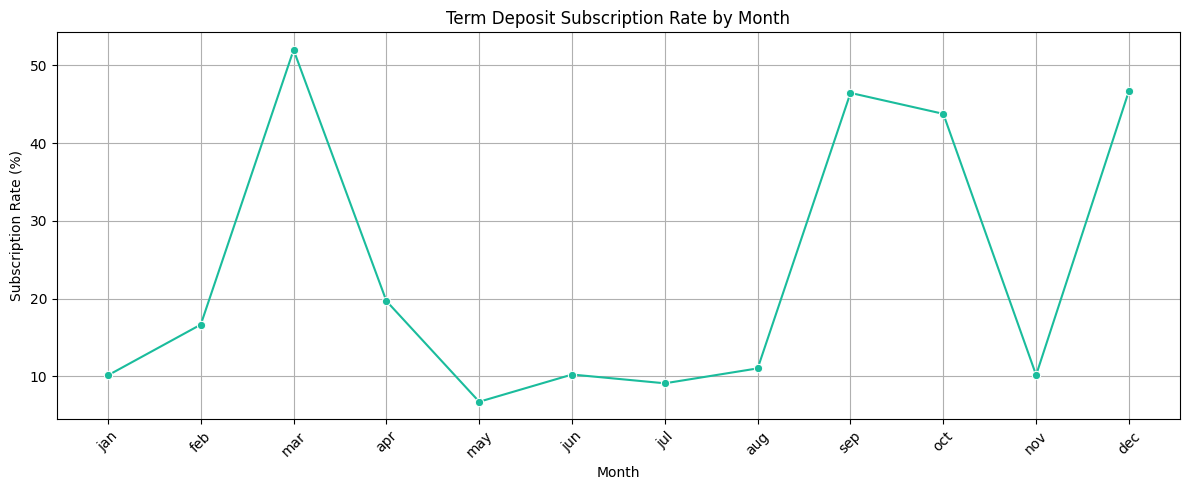

In [20]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = df['month'].str.lower()
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
conversion_by_month = df.groupby('month',observed=True)['y'].mean() * 100

plt.figure(figsize=(12, 5))
sns.lineplot(x=conversion_by_month.index, y=conversion_by_month.values, marker='o', color='#1ABC9C')
plt.title("Term Deposit Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
def plot_callDurationDistByFeature(feature):

    plt.figure(figsize=(15, 6))
    ax = sns.boxplot(x=feature, y='duration', hue='y', data=df, palette=['RED', 'BLUE'])
    plt.title(f"Call Duration Distribution by {feature} and Subscription Outcome")
    plt.xlabel("Day of Month" if feature=='day' else feature)
    plt.ylabel("Call Duration (seconds)")
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No', 'Yes'], title='Subscribed')
    
    plt.tight_layout()
    plt.show()

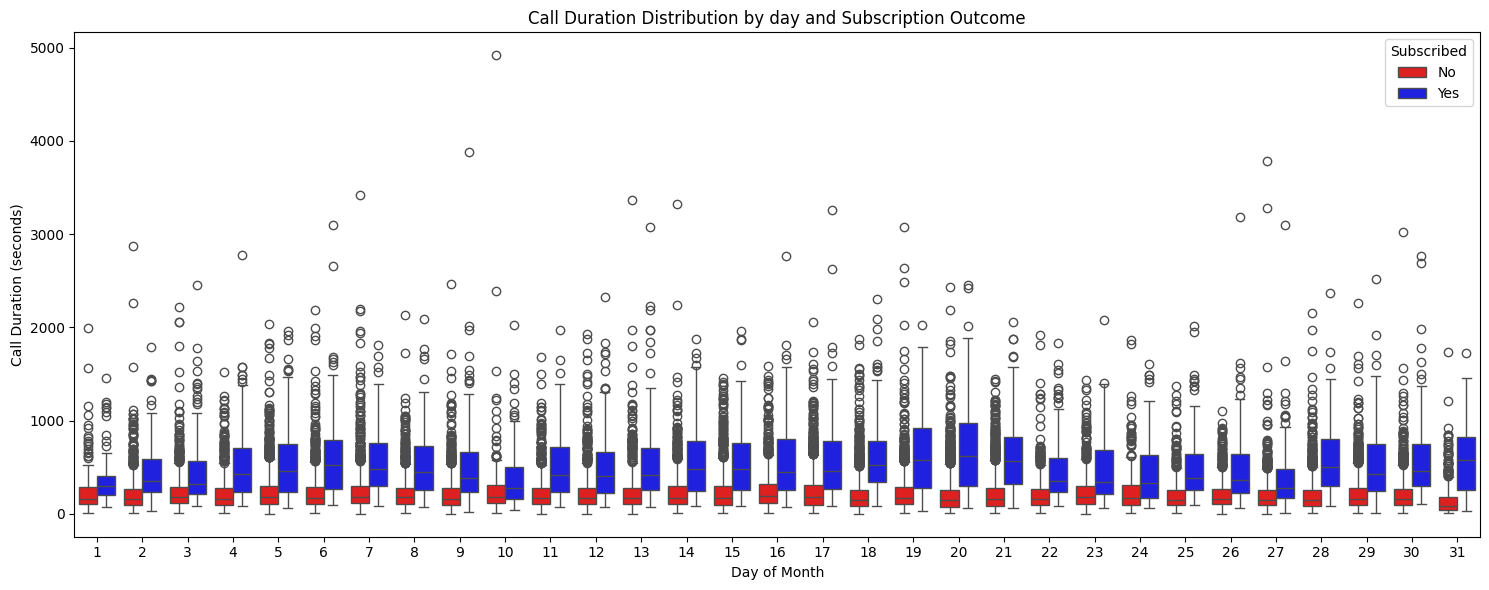

In [22]:
plot_callDurationDistByFeature('day')

OBSERVATIONS

1.Right skewed distribution amongst non subscribers
2.The duration of calls is higher for subscribers
3.Prescence of a significant number of outliers in the non subscriber segment, possibly indicates intrested people who have not subscribed.
4.Across all days, the call duration is higher for the subscibers.

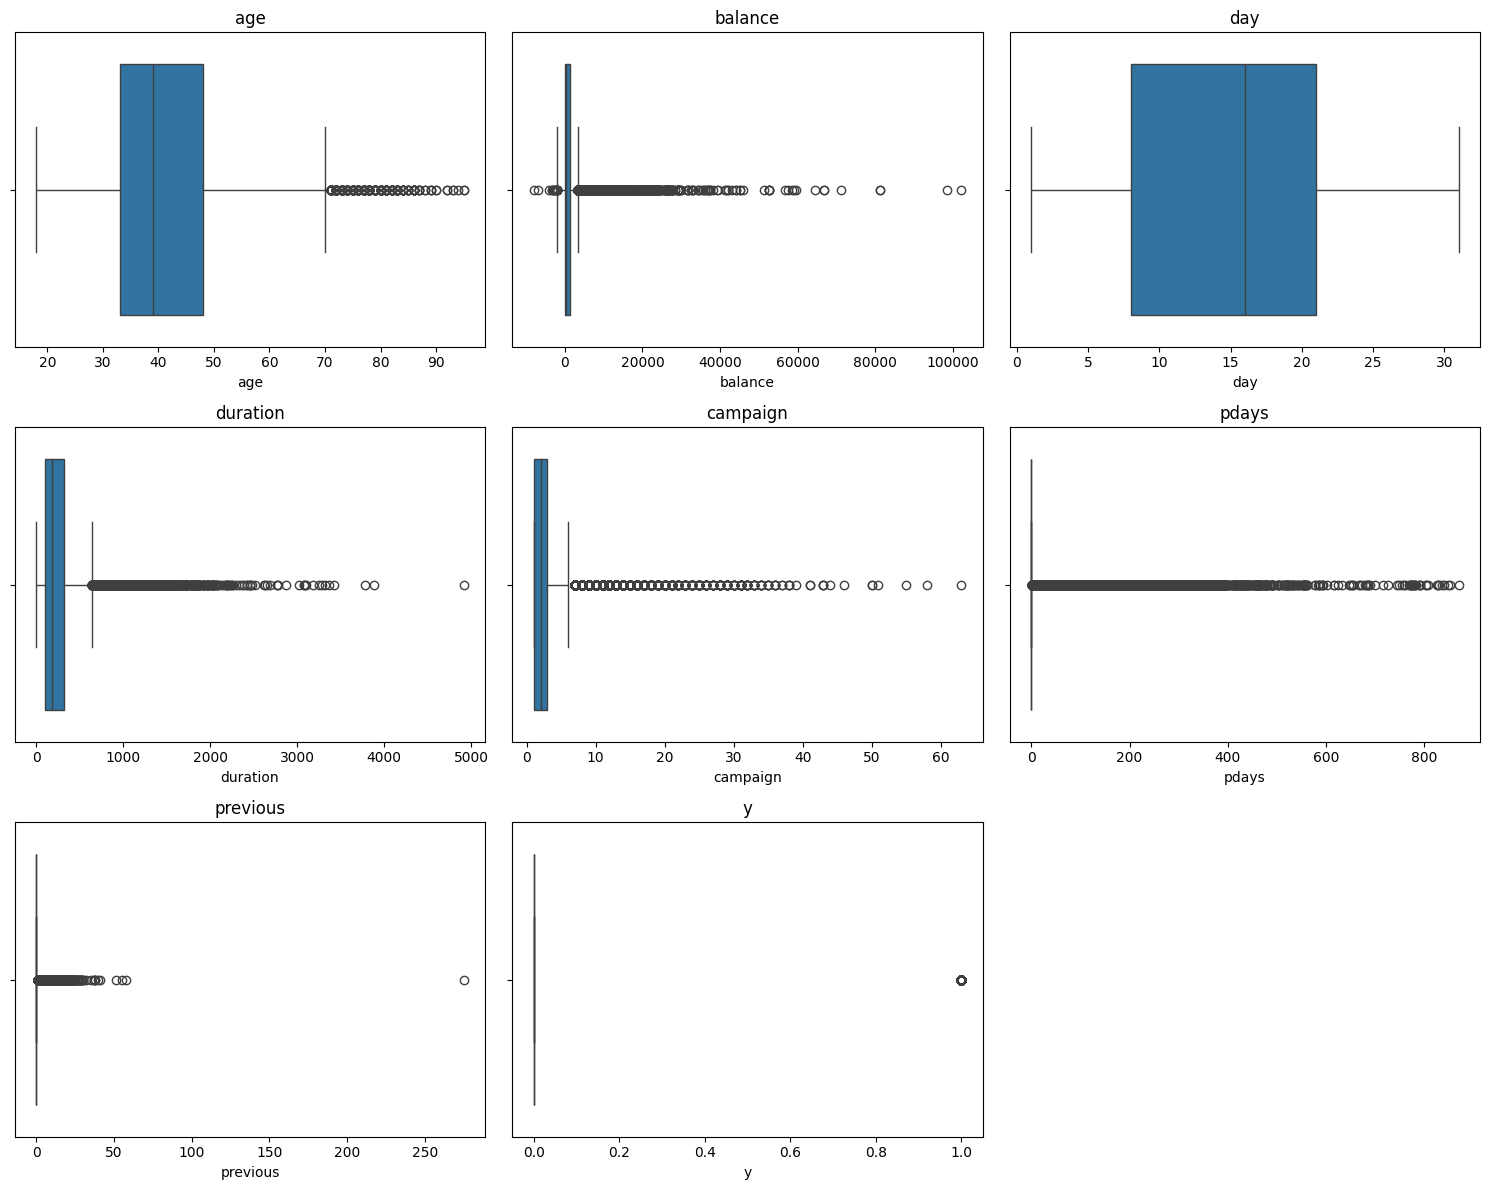

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

# Remove unused subplots
for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

Transformations to be Applied:
1.Age: Continuous,Log tranformton be applied for outliers, will be done after data split
2.Balance:Continuous,Log tranformto be applied for outliers, will be done after data split
3.Day:Ordinal,No change.
4.Duration:Continuous,Log transform, will be done after data split
5.Campaign:Discrete, create bins.
6.Month:Categorical,One hot encoding, will be done before data split
7.Job:Categorical,One hot encoding, will be done before data split
8.Marital:Categorical,One hot encoding, will be done before data split
9.Education:Categorical,Ordinal encoding, will be done before data split
10.Default:Binary Encoding, will be done before data split
11.housing:Binary Encoding, will be done before data split
12.Loan:Binary Encoding, will be done before data split
13.Contact:Nominal Encoding, will be done before data split
14.y:Binary

Moreover, we had observed spikes in the beginning and end of the month in rate of subscription.This may indicate underlying factors like:

1.More inclined on deposits during the beginning/end of month
2.Usually, people must have recieved salary or are making plans at the beginning of the month.
3.Also possible that highly inclined customers are pursued aggresively by agents at the beginning/end of the month.

In [24]:
#Add an additional column to indicate if the day falls at the beginning, middle, or end of the month.The beginning is defined as 1 to 3 and the end is defined as 29 to 31. Rest is middle.
#Beginning and end are defined as priority days and rest are non-priority days.

df["day_type"]=df["day"].apply(lambda x: 'P' if 1 <= x <= 3 or 29 <= x <= 31 else 'NP')
day_type_dummies=pd.get_dummies(df["day_type"], prefix="day_type", drop_first=True)
df=pd.concat([df, day_type_dummies], axis=1)
df.drop("day_type", axis=1, inplace=True)




In [25]:
#binning the campaing variable
df['campaign_group'] = pd.cut(df['campaign'],
                               bins=[0, 1, 2, 3, 5, np.inf],
                               labels=['0-1', '1-2', '2-3', '3-5', '>5'],
                               right=True)



In [26]:
campaign_group_dummies = pd.get_dummies(df['campaign_group'], prefix='campaign_group',drop_first=True)
df = pd.concat([df, campaign_group_dummies], axis=1)
df.drop(columns='campaign_group', inplace=True)

Encode the month,job,marital,education and binary encode for default, housing and loan

In [27]:
c1=["job", "marital", "month","poutcome"]
c2=["default", "housing", "loan"]

for i in c1:
    t=pd.get_dummies(df[i], prefix=i, drop_first=True)
    df=pd.concat([df,t], axis=1)
    df.drop(i, axis=1, inplace=True)

for i in c2:
    df[i]=df[i].map({'yes':1,'no':0})


df['education']=df['education'].map({'primary':1,'secondary':2,'tertiary':3,"Unknown":0})

contact_dummies = pd.get_dummies(df['contact'], prefix='contact',drop_first=True)
df = pd.concat([df, contact_dummies], axis=1)
df.drop('contact', axis=1, inplace=True)

In [28]:

df.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'day_type_P',
       'campaign_group_1-2', 'campaign_group_2-3', 'campaign_group_3-5',
       'campaign_group_>5', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_married', 'marital_single', 'month_feb',
       'month_mar', 'month_apr', 'month_may', 'month_jun', 'month_jul',
       'month_aug', 'month_sep', 'month_oct', 'month_nov', 'month_dec',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'contact_telephone', 'contact_unknown'],
      dtype='str')

In [29]:
X = df[[
    'age', 'balance',"default" ,"housing", "loan",

    'day_type_P','pdays', 'previous',

    'campaign_group_1-2', 'campaign_group_2-3',
    'campaign_group_3-5', 'campaign_group_>5',

    'month_apr', 'month_feb', 'month_mar', 'month_may',
    'month_jun', 'month_jul', 'month_aug', 'month_sep',
    'month_oct', 'month_nov', 'month_dec',

    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_retired', 'job_self-employed', 'job_services',
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown',

    'marital_married', 'marital_single',

    'education',
    'contact_telephone', 'contact_unknown',
    'poutcome_other', 'poutcome_success', 'poutcome_unknown'
]]

<Axes: ylabel='age'>

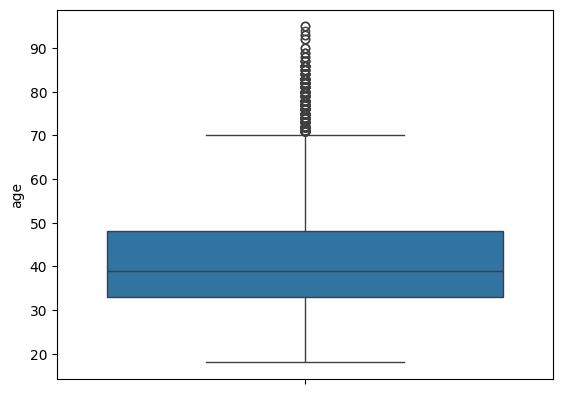

In [30]:
sns.boxplot(df["age"])

In [31]:
Y=df['y']

In [32]:
X.shape, Y.shape

((45211, 42), (45211,))

In [33]:
Y.value_counts(normalize=True)

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

#Considering the imbalance in the data,so we combine oversampling of minority class and undersampling of majority class to balance out the data.

In [34]:
from sklearn.model_selection import train_test_split
import random

In [35]:
seed=17
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, random_state=seed, test_size=0.2)

In [36]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [37]:
over = RandomOverSampler(sampling_strategy=0.5, random_state=seed)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=seed)

steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps)
X_resampled, y_resampled = pipeline.fit_resample(X_train, y_train)


In [38]:
y_resampled.value_counts(normalize=True)

y
0    0.5
1    0.5
Name: proportion, dtype: float64

In [39]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

In [40]:
X_resampled["education"] = X_resampled["education"].fillna(0)
X_test["education"] = X_test["education"].fillna(0)
X_resampled["education"].value_counts()

education
2.0    15651
3.0    10574
1.0     4219
0.0     1492
Name: count, dtype: int64

In [41]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

for i in ['age', 'balance']:
    X_resampled[[i]] = pt.fit_transform(X_resampled[[i]])
    X_test[[i]] = pt.transform(X_test[[i]])




In [42]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier,AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=seed),
    "RandomForest":       RandomForestClassifier(n_jobs=-1, random_state=seed),
    "ExtraTrees":         ExtraTreesClassifier(n_jobs=-1, random_state=seed),
    "GradientBoosting":   GradientBoostingClassifier(random_state=seed),
    "AdaBoost":          AdaBoostClassifier(random_state=seed),
    "LightGBM":           LGBMClassifier(n_jobs=-1, random_state=seed),
    "XGBoost":            XGBClassifier(
                                n_jobs=-1,
                                random_state=seed,
                                eval_metric='logloss'
                            ),
}

results = []

for name, model in models.items():
    model.fit(X_resampled, y_resampled)

    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("Recall", ascending=False))

[LightGBM] [Info] Number of positive: 15968, number of negative: 15968
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 31936, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                Model  Accuracy  Precision    Recall        F1
4            AdaBoost  0.697777   0.226932  0.657845  0.337455
3    GradientBoosting  0.788234   0.302989  0.622873  0.407671
0  LogisticRegression  0.751521   0.262675  0.621928  0.369352
5            LightGBM  0.805485   0.323958  0.609641  0.423090
6             XGBoost  0.806591   0.322182  0.591682  0.417194
1        RandomForest  0.855579   0.398361  0.459357  0.426690
2          ExtraTrees  0.853367   0.378623  0.395085  0.386679


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    
    AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pandas as pd

X_train['education'] = X_train['education'].fillna(0)

# columns to transform
transform_cols = ['age', 'balance']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'yeojohnson',
            PowerTransformer(method='yeo-johnson'),
            transform_cols
        )
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=seed),
    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=seed
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_jobs=-1,
        random_state=seed
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=seed
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=seed
    ),
    "XGBoost": XGBClassifier(
        n_jobs=-1,
        random_state=seed,
        eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        n_jobs=-1,
        random_state=seed
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('transform', preprocessor),


        ('over', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=seed
        )),

        ('under', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=seed
        )),

        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values('Recall', ascending=False)
    .round(4)
)

                Model  Accuracy  Precision  Recall      F1
4            AdaBoost    0.7037     0.2347  0.6722  0.3476
0  LogisticRegression    0.7534     0.2670  0.6332  0.3755
3    GradientBoosting    0.7921     0.3095  0.6287  0.4147
6            LightGBM    0.8109     0.3309  0.6029  0.4273
5             XGBoost    0.8059     0.3161  0.5656  0.4055
1        RandomForest    0.8558     0.3960  0.4417  0.4176
2          ExtraTrees    0.8529     0.3721  0.3746  0.3733


#Pre call modelling using only variables available before the call which are static

In [44]:

static_data = [
    'age', 'balance',"default" ,"housing", "loan",

    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_retired', 'job_self-employed', 'job_services',
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown',

    'marital_married', 'marital_single',

    'education'
]



X2 = df[static_data]

y2 = df['y']

In [45]:
X2["education"].fillna(0, inplace=True)

C:\Users\PAVILION\AppData\Local\Temp\ipykernel_1880\932740788.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X2["education"].fillna(0, inplace=True)


0        3.0
1        2.0
2        2.0
3        0.0
4        0.0
        ... 
45206    3.0
45207    1.0
45208    2.0
45209    2.0
45210    2.0
Name: education, Length: 45211, dtype: float64

In [46]:
X_stat_train, X_stat_test, y_stat_train, y_stattest = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2   # recommended for classification
)

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pandas as pd

# Fill missing values
X_stat_train["education"] = X_stat_train["education"].fillna(0)
X_stat_test["education"] = X_stat_test["education"].fillna(0)

# Columns to transform
transform_cols = ['age', 'balance']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'yeojohnson',
            PowerTransformer(method='yeo-johnson'),
            transform_cols
        )
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=seed
    ),

    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=seed
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=seed
    ),

    "XGBoost": XGBClassifier(
        n_jobs=-1,
        random_state=seed,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_jobs=-1,
        random_state=seed,
        verbose=-1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('transform', preprocessor),

        ('over', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=seed
        )),

        ('under', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=seed
        )),

        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_stat_train,
        y_stat_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean(),
        'Balanced Accuracy': scores['test_balanced_accuracy'].mean()
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values('Recall', ascending=False)
    .round(4)
)

                Model  Accuracy  Precision  Recall      F1  ROC AUC  \
4            AdaBoost    0.6465     0.1910  0.6251  0.2925   0.6865   
0  LogisticRegression    0.6329     0.1830  0.6169  0.2822   0.6695   
3    GradientBoosting    0.6859     0.2053  0.5873  0.3043   0.6925   
6            LightGBM    0.7204     0.2215  0.5526  0.3162   0.6962   
5             XGBoost    0.7232     0.2170  0.5238  0.3069   0.6802   
1        RandomForest    0.7987     0.2668  0.4117  0.3237   0.6761   
2          ExtraTrees    0.8033     0.2587  0.3642  0.3024   0.6558   

   Balanced Accuracy  
4             0.6372  
0             0.6260  
3             0.6431  
6             0.6476  
5             0.6367  
1             0.6308  
2             0.6128  


Notice that Adaboost is the best model

In [48]:
pre_model_1=models["AdaBoost"]

In [49]:
df.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'day_type_P',
       'campaign_group_1-2', 'campaign_group_2-3', 'campaign_group_3-5',
       'campaign_group_>5', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_married', 'marital_single', 'month_feb',
       'month_mar', 'month_apr', 'month_may', 'month_jun', 'month_jul',
       'month_aug', 'month_sep', 'month_oct', 'month_nov', 'month_dec',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'contact_telephone', 'contact_unknown'],
      dtype='str')

In [50]:
campaign_features = [    'age', 'balance',"default" ,"housing", "loan",

    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_retired', 'job_self-employed', 'job_services',
    'job_student', 'job_technician', 'job_unemployed', 'job_unknown',

    'marital_married', 'marital_single',

    'education','day_type_P', 'campaign_group_1-2', 'campaign_group_2-3',
    'campaign_group_3-5', 'campaign_group_>5','month_feb', 'month_mar', 'month_apr', 'month_may', 'month_jun',
    'month_jul', 'month_aug', 'month_sep', 'month_oct', 'month_nov',
    'month_dec','contact_telephone', 'contact_unknown','pdays', 'previous', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']
    

In [51]:
X3=df[campaign_features]
X3.head()
y3=df['y']


In [52]:
X_campaign_train, X_campaign_test, y_campaign_train, y_campaign_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3   # recommended for classification
)

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import pandas as pd

# Fill missing values
X_campaign_train["education"] = X_campaign_train["education"].fillna(0)
X_campaign_test["education"] = X_campaign_test["education"].fillna(0)

# Columns to transform
transform_cols = ['age', 'balance']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'yeojohnson',
            PowerTransformer(method='yeo-johnson'),
            transform_cols
        )
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=seed
    ),

    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_jobs=-1,
        random_state=seed
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=seed
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=seed
    ),

    "XGBoost": XGBClassifier(
        n_jobs=-1,
        random_state=seed,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_jobs=-1,
        random_state=seed,
        verbose=-1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('transform', preprocessor),

        ('over', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=seed
        )),

        ('under', RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=seed
        )),

        ('model', model)
    ])

    scores = cross_validate(
        pipeline,
        X_campaign_train,
        y_campaign_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )

    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC AUC': scores['test_roc_auc'].mean(),
        'Balanced Accuracy': scores['test_balanced_accuracy'].mean()
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values(['F1','ROC AUC'], ascending=False)
    .round(4)
)

                Model  Accuracy  Precision  Recall      F1  ROC AUC  \
6            LightGBM    0.8134     0.3340  0.5975  0.4284   0.7797   
1        RandomForest    0.8570     0.3999  0.4443  0.4210   0.7599   
3    GradientBoosting    0.7959     0.3130  0.6211  0.4161   0.7816   
5             XGBoost    0.8078     0.3170  0.5559  0.4037   0.7569   
2          ExtraTrees    0.8544     0.3771  0.3746  0.3758   0.7345   
0  LogisticRegression    0.7540     0.2666  0.6289  0.3744   0.7650   
4            AdaBoost    0.6899     0.2261  0.6802  0.3393   0.7575   

   Balanced Accuracy  
6             0.7198  
1             0.6780  
3             0.7201  
5             0.6985  
2             0.6463  
0             0.6997  
4             0.6857  


In [54]:
Pre_model_2=models["LightGBM"]



Two stage prediction with Adaboost and Light GBM

In [55]:
def combined_pipeline(df, model_1, model_2, precall, beforecall, threshold=0.5):

    df = df.copy()
    df["stage1_prob"] = model_1.predict_proba(df[precall])[:, 1]

    df2 = df[df["stage1_prob"] >= threshold].copy()

    if df2.empty:
        df['stage2_prob'] = 0.0
        df['final_score'] = 0.0
        return df

    df2["stage2_prob"] = model_2.predict_proba(df2[beforecall])[:, 1]
    df2['final_score'] = df2['stage1_prob'] * df2['stage2_prob']

    df = df.merge(df2[['stage2_prob', 'final_score']],
                   left_index=True, right_index=True, how='left')
    df['stage2_prob'] = df['stage2_prob'].fillna(0)
    df['final_score'] = df['final_score'].fillna(0)
    return df

In [56]:
from imblearn.pipeline import Pipeline as ImbPipeline

In [57]:
# Cell 64 (corrected) - split transformer from resampler

# columns to transform
transform_cols = ['age', 'balance']

# Resampling-only pipeline (NO transformer here -- transformer is
# handled separately so we can fit on train and only transform on test)
resample_pipeline = ImbPipeline([
    ('over', RandomOverSampler(sampling_strategy=0.5, random_state=seed)),
    ('under', RandomUnderSampler(sampling_strategy=1.0, random_state=seed)),
])


def make_transformer():
    """Returns a fresh ColumnTransformer for age/balance yeo-johnson."""
    return ColumnTransformer(
        transformers=[
            ('yeojohnson', PowerTransformer(method='yeo-johnson'), transform_cols)
        ],
        remainder='passthrough'
    )


def apply_transform(transformer, X, columns, fit=False):
    """
    Apply a ColumnTransformer and return a DataFrame with original
    column order/names and dtypes preserved.
    NOTE: ColumnTransformer with remainder='passthrough' reorders columns
    (transformed cols first, then passthrough cols), so we rebuild the
    column order explicitly.
    """
    if fit:
        arr = transformer.fit_transform(X)
    else:
        arr = transformer.transform(X)

    passthrough_cols = [c for c in columns if c not in transform_cols]
    new_col_order = transform_cols + passthrough_cols

    out = pd.DataFrame(arr, columns=new_col_order, index=X.index)
    out = out[columns]  # restore original column order
    out = out.astype(X.dtypes.to_dict())
    return out

In [58]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score



In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

fold_metrics = {
    'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': [], 'ROC AUC': []
}

for fold, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_fold_test, y_fold_test = X_train.iloc[test_idx], y_train.iloc[test_idx]

    # 1) Fit transformer on fold-train ONLY, transform fold-train and fold-test
    transformer = make_transformer()
    X_fold_train_t = apply_transform(transformer, X_fold_train, X_fold_train.columns, fit=True)
    X_fold_test_t  = apply_transform(transformer, X_fold_test,  X_fold_test.columns,  fit=False)

    # 2) Resample the (already transformed) training fold
    X_resampled, y_resampled = resample_pipeline.fit_resample(X_fold_train_t, y_fold_train)
    X_resampled = pd.DataFrame(X_resampled, columns=X_fold_train_t.columns)
    y_resampled = pd.Series(y_resampled)
    X_resampled = X_resampled.astype(X_fold_train_t.dtypes.to_dict())

    # 3) Train models on resampled+transformed data
    model_1 = clone(pre_model_1).fit(X_resampled[static_data], y_resampled)
    model_2 = clone(Pre_model_2).fit(X_resampled[campaign_features], y_resampled)

    # 4) Evaluate on transformed fold-test (consistent with training distribution)
    combined_results = combined_pipeline(
        X_fold_test_t,
        model_1,
        model_2,
        precall=static_data,
        beforecall=campaign_features,
        threshold=0.5
    )

    combined_results["y_true"] = y_fold_test.values
    combined_results["y_pred"] = (combined_results["final_score"] >= 0.5).astype(int)

    fold_metrics['Accuracy'].append(accuracy_score(y_fold_test, combined_results['y_pred']))
    fold_metrics['Precision'].append(precision_score(y_fold_test, combined_results['y_pred'], zero_division=0))
    fold_metrics['Recall'].append(recall_score(y_fold_test, combined_results['y_pred'], zero_division=0))
    fold_metrics['F1 Score'].append(f1_score(y_fold_test, combined_results['y_pred'], zero_division=0))
    fold_metrics['ROC AUC'].append(roc_auc_score(y_fold_test, combined_results['final_score']))

In [60]:
avg_result = {metric: np.mean(scores) for metric, scores in fold_metrics.items()}
print("\nAverage Cross-Validation Results (Two-Stage Pipeline):")
for metric, value in avg_result.items():
    print(f"{metric}: {value:.4f}")


Average Cross-Validation Results (Two-Stage Pipeline):
Accuracy: 0.8859
Precision: 0.5301
Recall: 0.2210
F1 Score: 0.3118
ROC AUC: 0.6974


In [61]:
# Final model fit (for the held-out X_test evaluation)
# Fit transformer + resampler + models on the FULL X_train,
# then transform X_test with the SAME fitted transformer.

final_transformer = make_transformer()
X_train_t = apply_transform(final_transformer, X_train, X_train.columns, fit=True)
X_test_t  = apply_transform(final_transformer, X_test,  X_test.columns,  fit=False)

X_train_resampled, y_train_resampled = resample_pipeline.fit_resample(X_train_t, y_train)
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_t.columns)
y_train_resampled = pd.Series(y_train_resampled)
X_train_resampled = X_train_resampled.astype(X_train_t.dtypes.to_dict())

pre_step1A_model = clone(pre_model_1).fit(X_train_resampled[static_data], y_train_resampled)
pre_step1B_model = clone(Pre_model_2).fit(X_train_resampled[campaign_features], y_train_resampled)

In [62]:
# Cell 68 (corrected) - threshold tuning on TRANSFORMED X_test

X_test_t = X_test_t.fillna(0)

results = []
stage1_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
final_score_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for t1 in stage1_thresholds:
    for t2 in final_score_thresholds:
        df_preds = combined_pipeline(
            X_test_t,
            pre_step1A_model,
            pre_step1B_model,
            precall=static_data,
            beforecall=campaign_features,
            threshold=t1
        )

        df_preds['final_pred'] = (df_preds['final_score'] >= t2).astype(int)

        acc = accuracy_score(y_test, df_preds['final_pred'])
        prec = precision_score(y_test, df_preds['final_pred'], zero_division=0)
        rec = recall_score(y_test, df_preds['final_pred'], zero_division=0)
        f1 = f1_score(y_test, df_preds['final_pred'], zero_division=0)
        roc = roc_auc_score(y_test, df_preds['final_score'])

        results.append({
            'Stage1_Thresh': t1,
            'FinalScore_Thresh': t2,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc
        })

threshold_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
display(threshold_df)

,Stage1_Thresh,FinalScore_Thresh,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.1,0.1,0.351543,0.143366,0.913043,0.247819,0.760710
14,0.3,0.1,0.351543,0.143366,0.913043,0.247819,0.760710
7,0.2,0.1,0.351543,0.143366,0.913043,0.247819,0.760710
21,0.4,0.1,0.388146,0.147138,0.881853,0.252196,0.752812
1,0.1,0.2,0.651664,0.212321,0.729679,0.328931,0.760710
8,0.2,0.2,0.651664,0.212321,0.729679,0.328931,0.760710
15,0.3,0.2,0.651664,0.212321,0.729679,0.328931,0.760710
22,0.4,0.2,0.653765,0.211683,0.719282,0.327101,0.752812
28,0.5,0.1,0.577353,0.176650,0.713611,0.283196,0.713518
29,0.5,0.2,0.702201,0.225579,0.635161,0.332920,0.713518


CAMPAIGN SIMULATION

In [65]:
import itertools
import pandas as pd

# ------------------------------------------------------------
# Reference categories (dropped during one-hot encoding):
#   contact      -> 'cellular' is the reference (contact_telephone=0, contact_unknown=0)
#   campaign_grp -> '0-1' is the reference (all campaign_group_* dummies = 0)
#   day_type     -> reference category is 0 (day_type_P = 0)
#   month        -> 'jul' is explicitly forced to 1 (kept as in original)
# ------------------------------------------------------------

contact_options = ['cellular', 'telephone', 'unknown']
day_type_p_options = [0, 1]   # day_type_P = 0 or 1



# Define these separately and explicitly
campaign_dummy_cols = [
    'contact_telephone', 'contact_unknown',  # contact dummies
    'day_type_P',                             # day type
    'month_apr', 'month_feb', 'month_mar',   # month dummies
    'month_may', 'month_jun', 'month_jul',
    'month_aug', 'month_sep', 'month_oct', 'month_nov'
]

def generate_campaign_variants(df_row):
    variants = []
    for contact, day_type_p in itertools.product(contact_options, day_type_p_options):
        row_copy = df_row.copy()

        # zero out ONLY campaign dummies, not customer features
        for feat in campaign_dummy_cols:
            row_copy[feat] = 0

        # restore campaign history bucket
        for group_feat in campaign_dummy_cols:
            if group_feat in df_row and df_row[group_feat] == 1:
                row_copy[group_feat] = 1

        row_copy['month_jul'] = 1

        if contact != 'cellular':
            row_copy[f'contact_{contact}'] = 1

        row_copy['day_type_P'] = day_type_p

        variants.append(row_copy)

    return pd.DataFrame(variants)

In [66]:
test_variants = pd.concat([generate_campaign_variants(row) for _, row in X_test.iterrows()], ignore_index=True)


In [67]:
test_variants.shape

(54258, 42)

In [68]:
df_preds = combined_pipeline(
    test_variants, 
    pre_step1A_model, 
    pre_step1B_model, 
    static_data, 
    campaign_features,
)

# Add simulated 'client id' (repeat each index 6 times)
df_preds['client_id'] = np.repeat(X_test.index, len(contact_options) * len(day_type_p_options))

In [69]:
top_scenarios = df_preds.groupby('client_id').apply(lambda df: df.loc[df['final_score'].idxmax()]).reset_index()


In [70]:
top_candidates = top_scenarios.sort_values(by='final_score', ascending=False)
top_candidates[['client_id', 'final_score', 'day_type_P', 'contact_telephone', 'contact_unknown' ]].head(30)

,client_id,final_score,day_type_P,contact_telephone,contact_unknown
8581,42824,0.784553,0,1,0
8443,42120,0.758668,1,1,0
8584,42827,0.753066,0,1,0
8892,44403,0.742174,0,0,0
8761,43698,0.734296,1,0,0
8924,44582,0.727527,0,0,0
8097,40368,0.726390,1,0,0
8467,42265,0.725786,1,1,0
8556,42709,0.725069,0,0,0
8615,42995,0.718511,0,0,0


Business results

In [71]:
df_results = combined_pipeline(
            X_test,
            pre_step1A_model,
            pre_step1B_model,
            static_data,
            campaign_features,
            threshold=0.5
        )

In [81]:
df_results.shape
X_test.shape

(9043, 42)

In [72]:
df_results['y_true'] = y_test.loc[df_results.index].values

In [83]:
efficiency = {
    'threshold': [],
    'calls_made': [],
    'calls_saved': [],
    'subscribers_reached': [],
    'call_efficiency_1': [],
    'call_efficiency_2': []
}

baseline_calls = len(df_results)  # all clients in test set, called following the traditional strategy
for threshold in np.arange(0.01, 1.001, 0.01):
    preds = df_results['final_score'] > threshold
    y_true = df_results['y_true']

    TP = ((preds == True) & (y_true == 1)).sum()
    FP = ((preds == True) & (y_true == 0)).sum()
    FN = ((preds == 0) & (y_true == 1)).sum()
    
    calls_made = TP + FP
    truth_subscribers = TP + FN
    calls_saved = baseline_calls - calls_made
    call_efficiency_1 = TP / calls_made if calls_made else 0  # precision
    call_efficiency_2 = TP / truth_subscribers if truth_subscribers else 0  # recall
    
    efficiency['threshold'].append(threshold)
    efficiency['calls_made'].append(calls_made)
    efficiency['calls_saved'].append(calls_saved)
    efficiency['subscribers_reached'].append(TP)
    efficiency['call_efficiency_1'].append(call_efficiency_1)
    efficiency['call_efficiency_2'].append(call_efficiency_2)

df_eff = pd.DataFrame(efficiency)

In [84]:
early_df = df_eff[df_eff['threshold'] < 0.5].copy()
early_df['diff_prec_recall'] = (early_df['call_efficiency_2'] - early_df['call_efficiency_1']).abs()
intersection_row = early_df.loc[early_df['diff_prec_recall'].idxmin()]
threshold = intersection_row['threshold']
precision = intersection_row['call_efficiency_1']

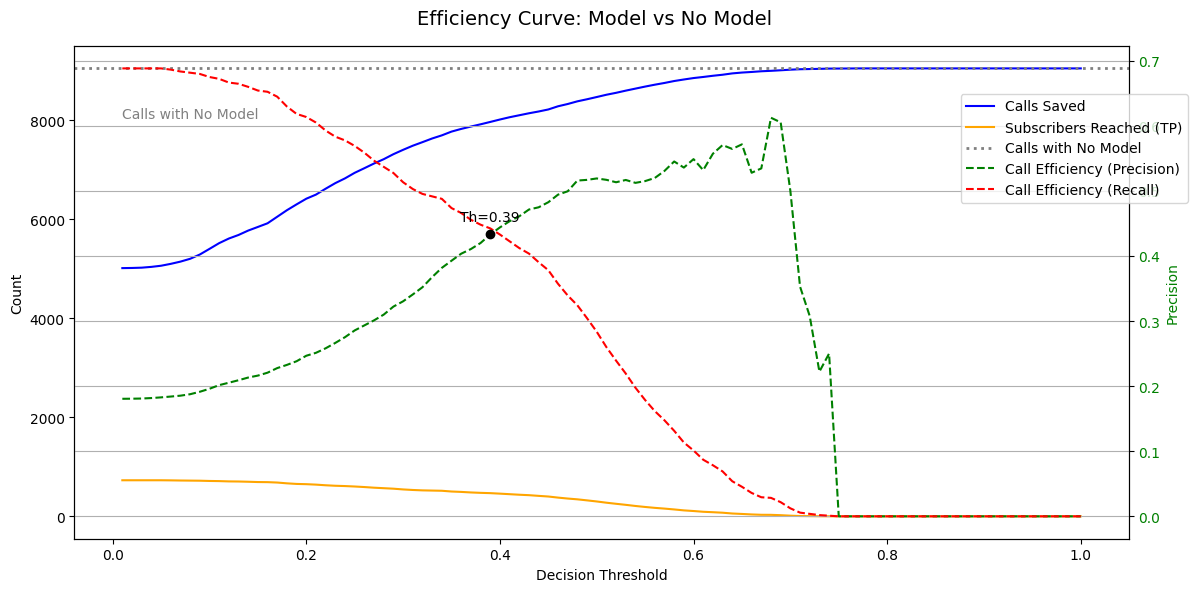

In [86]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# primary Y-axis (Counts)
ax1.plot(df_eff['threshold'], df_eff['calls_saved'], label='Calls Saved', color='blue')
ax1.plot(df_eff['threshold'], df_eff['subscribers_reached'], label='Subscribers Reached (TP)', color='orange')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Count', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Add a reference line at 8000 (total calls without the model)
ax1.axhline(y=len(df_results), color='gray', linestyle=':', linewidth=2, label='Calls with No Model')
ax1.text(0.01, 8050, 'Calls with No Model', color='gray', fontsize=10)

# secondary Y-axis (Precision)
ax2 = ax1.twinx()
ax2.plot(df_eff['threshold'], df_eff['call_efficiency_1'], label='Call Efficiency (Precision)', color='green', linestyle='--')
ax2.plot(df_eff['threshold'], df_eff['call_efficiency_2'], label='Call Efficiency (Recall)', color='red', linestyle='--')
# Plot intersection point
ax2.plot(threshold, precision, 'ko')  # black dot
ax2.annotate(f'Th={threshold:.2f}', (threshold, precision), textcoords="offset points", xytext=(0,10), ha='center', color='black')
ax2.set_ylabel('Precision', color='green')
ax2.tick_params(axis='y', labelcolor='green')

fig.suptitle('Efficiency Curve: Model vs No Model', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(1, 0.85))
fig.tight_layout()
plt.grid(True)
plt.show()

In [87]:
baseline_calls = len(df_results)  # all clients in test set, called following the traditional strategy
total_positives = df_results['y_true'].sum()
model_tp = intersection_row['subscribers_reached']
model_calls = intersection_row['calls_made']

ratio_baseline_to_positives = baseline_calls / total_positives
ratio_model_calls_to_tp = model_calls / model_tp

In [88]:
print(f"Baseline strategy (no model): \t\t\t{ratio_baseline_to_positives:.1f} calls per positive subscription")
print(f"Model-based strategy (at threshold=0.19):\t{ratio_model_calls_to_tp:.1f} calls per positive subscription")

Baseline strategy (no model): 			8.5 calls per positive subscription
Model-based strategy (at threshold=0.19):	2.3 calls per positive subscription


In [89]:
duration_series = df.loc[X_test.index, 'duration'].copy()
df_results['duration'] = duration_series.values

In [90]:

# Baseline: all clients in test set are called
baseline_total_duration = df_results['duration'].sum()
baseline_total_positives = df_results['y_true'].sum()
baseline_duration_per_subscription = baseline_total_duration / baseline_total_positives

# Model: only predicted positives are called
df_results['predicted_positive'] = df_results['final_score'] > threshold
model_called = df_results[df_results['predicted_positive']]

model_total_duration = model_called['duration'].sum()
model_total_tp = ((model_called['y_true'] == 1)).sum()
model_duration_per_subscription = model_total_duration / model_total_tp

# Print results
print(f"Baseline total duration (all calls): \t{baseline_total_duration:.0f} seconds")
print(f"Baseline duration per subscription: \t{baseline_duration_per_subscription:.1f} seconds")

print(f"Model total duration (calls made): \t{model_total_duration:.0f} seconds")
print(f"Model duration per subscription: \t{model_duration_per_subscription:.1f} seconds")

print(f"Time efficiency improvement: \t\t{baseline_duration_per_subscription / model_duration_per_subscription:.2f}x")

Baseline total duration (all calls): 	2323013 seconds
Baseline duration per subscription: 	2195.7 seconds
Model total duration (calls made): 	316459 seconds
Model duration per subscription: 	676.2 seconds
Time efficiency improvement: 		3.25x
